In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

#data_gen from un_pool


np.random.seed(123)
# because using 42 gen data so that the 2 draws of c was 'coincidentally' matching
# with true mean making unpooled seem more accurate than partial

segments = {
    "Segment_A": {"true_mu": 35, "true_sigma": 4, "n": 50},  # Lots of data
    "Segment_B": {"true_mu": 28, "true_sigma": 3, "n": 30},  # Moderate data
    "Segment_C": {"true_mu": 40, "true_sigma": 5, "n": 2},   # ALMOST NO DATA
}


data_all = []
group_idx = []
group_names = []
for i, (name, params) in enumerate(segments.items()):
    samples = np.random.normal(params["true_mu"], params["true_sigma"], params["n"])
    data_all.extend(samples)
    group_idx.extend([i] * params["n"])
    group_names.append(name)
    print(f"{name}: n={params['n']}, true_mu={params['true_mu']}, sample_mean={samples.mean():.1f}")

data_all = np.array(data_all)
group_idx = np.array(group_idx)
n_groups = len(segments)

with pm.Model() as hierarchial_model:
    # Adding coords (dimension labels) so ArviZ knows the names of our segments in the plots
   # hierarchial_model.add_coord("segments", group_names)

    # hyper_prior
    mu_global = pm.Normal("mu_global", mu = 30, sigma=10)
    sigma_global = pm.HalfNormal("sigma_global", sigma =10)

    # group prior
    mu_segment = pm.Normal("mu_segment", mu = mu_global, sigma=sigma_global, shape=n_groups)
    sigma_segment = pm.HalfNormal("sigma_segment", sigma = sigma_global, shape=n_groups)


    # likelihood
    y = pm.Normal("y", mu = mu_segment[group_idx], sigma = sigma_segment[group_idx], observed=data_all)


    prior_checks = pm.sample_prior_predictive(draws=1000, random_seed=42 )
    trace_hier = pm.sample(draws=2000, tune=1000, cores=1, random_seed=42, progressbar=False)


fig, ax = plt.subplots(figsize=(8, 4))
az.plot_dist(prior_checks.prior_predictive["y"],
             color="grey",
             label="Prior Predictive (y)",
             ax=ax)
ax.set_title("Prior Predictive Checks")
ax.set_xlabel("Predicted UCS (MPa)")
plt.show()

# arviz deals with data, no blueprints
display(az.summary(trace_hier, var_names=["mu_global", "mu_segment"]))


az.plot_trace(trace_hier, var_names=["mu_global", "mu_segment"],
              compact=False, #
              kind="trace")
plt.suptitle("Convergence Check: Trace Plots")
plt.tight_layout()
plt.show()

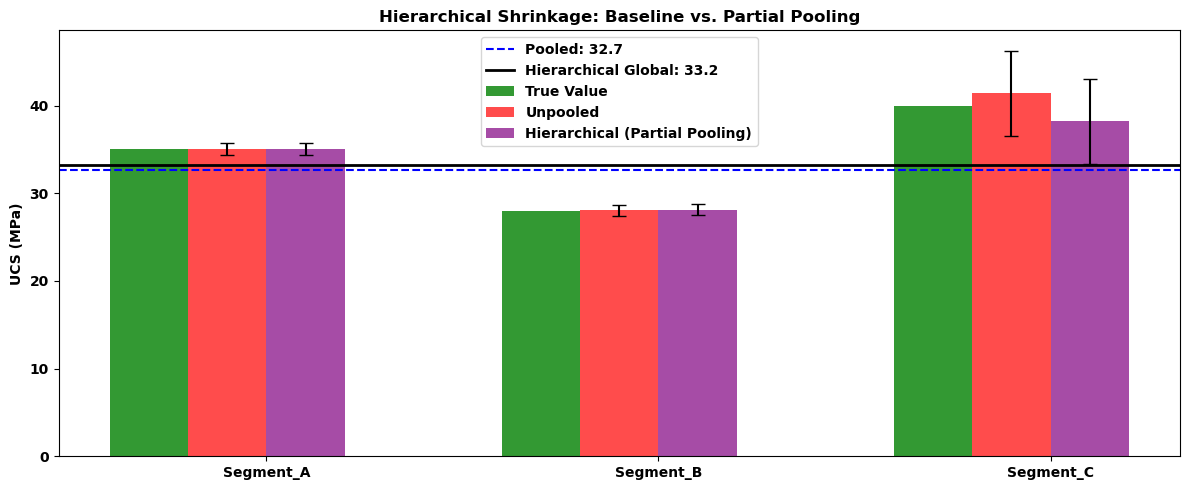

Segment_A: True=35, Unpooled=35.1±0.7, Hierarchical=35.0±0.7
Segment_B: True=28, Unpooled=28.1±0.6, Hierarchical=28.1±0.6
Segment_C: True=40, Unpooled=41.4±4.9, Hierarchical=38.2±4.8


In [17]:
hier_means = trace_hier.posterior["mu_segment"].values.reshape(-1, n_groups)
hier_global_mean = trace_hier.posterior["mu_global"].values.mean()

# Calculate Unpooled (Naïve) Estimates for the plot
unpooled_ests = [data_all[group_idx == i].mean() for i in range(n_groups)]

# Use Standard Error of the Mean (SEM), not raw Standard Deviation
# Raw Standard Deviation is just the physical spread of rocks, which doesn't shrink with more data.
# SEM measures how ignorant we are of the true average, which shrinks as n increases.
unpooled_sems = [data_all[group_idx == i].std(ddof=1) / np.sqrt(sum(group_idx == i))
                 if sum(group_idx == i) > 1 else np.nan for i in range(n_groups)]

pooled_mu = data_all.mean()

fig, ax = plt.subplots(figsize=(12, 5))
true_mus = [s["true_mu"] for s in segments.values()]

x_pos = np.arange(n_groups)
w = 0.2
ax.bar(x_pos - w*1.5, true_mus, w, label='True Value', color='green', alpha=0.8)


ax.bar(x_pos - w*0.5, unpooled_ests, w, label='Unpooled', color='red', alpha=0.7,
       yerr=unpooled_sems, capsize=5)

ax.bar(x_pos + w*0.5, [hier_means[:, i].mean() for i in range(n_groups)], w,
       label='Hierarchical (Partial Pooling)', color='purple', alpha=0.7,
       yerr=[hier_means[:, i].std() for i in range(n_groups)], capsize=5)


ax.axhline(pooled_mu, color='blue', linestyle='--', label=f'Pooled: {pooled_mu:.1f}')
ax.axhline(hier_global_mean, color='black', linestyle='-', linewidth=2, label=f'Hierarchical Global: {hier_global_mean:.1f}')

ax.set_xticks(x_pos)
ax.set_xticklabels(group_names)
ax.set_ylabel("UCS (MPa)")
ax.set_title("Hierarchical Shrinkage: Baseline vs. Partial Pooling")
ax.legend()
plt.tight_layout()
plt.show()


for i, name in enumerate(group_names):
    print(f"{name}: True={true_mus[i]}, Unpooled={unpooled_ests[i]:.1f}±{unpooled_sems[i]:.1f}, "
          f"Hierarchical={hier_means[:, i].mean():.1f}±{hier_means[:, i].std():.1f}")

# Why compare Unpooled SEM vs Hierarchical STD?
# They both measure the exact same thing: "Uncertainty of the Mean."
# In frequentist math (Unpooled), you calculate SEM to find the error of the mean.
# In Bayesian math (Hierarchical), PyMC's `mu_segment` is *already* a distribution of the mean.
# Therefore, the standard deviation of `mu_segment` IS the Bayesian equivalent of SEM.
# Even if they look similar in size, Partial Pooling drags the *anchor point* (the mean)
# away from extreme anomalies. This physically forces a safer design envelope.

### Mechanics of Partial Pooling

**1. Shrinkage (The Defense Mechanism)**
A Hierarchical model builds a "Global Prior" (`mu_global`) using all the mountain's data—mostly driven by the highly sampled Segments A and B. Because Segment C ($n=2$) belongs to the same geological structure, the model actively **pulls (shrinks) C's extreme estimate away from its raw isolated data and toward the global average.** The strong shield the weak. This prevents commercial liability from statistical flukes on tiny datasets.

**2. Variance Weighting (The Trust Protocol)**
Why did Segment A's estimate barely move, while Segment C's moved massively? The model dynamically weights evidence. 
* **High Data (Segment A, $n=50$):** The model sees massive evidence. It says, *"I trust this local data. I don't need the global prior."* Shrinkage is near zero.
* **Low Data (Segment C, $n=2$):** The model sees a data void. It says, *"I cannot trust these two rocks. I will rely heavily on the mountain's overarching baseline."* Shrinkage is extreme. 
You don't have to manually decide what $n$ is "enough"—the model mathematically negotiates trust using variance.

**3. Neal's Funnel (The Sampler's Nightmare)**
As a hierarchical model simulates reality, it explores what happens if the global variance (`sigma_global`) gets very small. As this variance approaches zero, the math forces all individual segment means (`mu_segment`) to collapse into the exact same value. 
Graphically, this looks like a steep V-shaped funnel. The bottom of the funnel is so narrow that the MCMC sampler crashes into the walls, causing a **"Divergence."** This is precisely why we sometimes increase `target_accept = 0.90`—to force the sampler to take smaller, more careful steps as it navigates the tight physical geometry of the funnel.

**4. Prior vs. Prior Predictive Checks (The Forensics)**
* **Prior Check:** Looking at the abstract parameter distributions (e.g., "What does `mu_global` look like?").
* **Prior Predictive Check:** Running those abstract parameters *forward* through the mathematical machinery (the Likelihood function) to simulate fully realized, physical "fake data" (`y`). 
